For this script, we will focus on the intron bursting comparison between ecDNA and chr7. From the previous script , we have obtained the individual chromatin traces. Now, with the processed smFISH on each intron on ecEGFR, we could link these molecules to individual traces

Relevant figures can be found in Figure 1, Extended Data Figure 3

In [2]:
import os
import numpy as np
import pandas as pd
import sys

In [3]:
sys.path.append('../scripts/')
from ioMicroS6A import *
from ecDNATracer_HelperFunctions import *
from plot import *

# compute the bursting rate per gene

In [10]:
chr7_iQs = [20, 22, 24, 26, 30, 32, 37, 39, 41, 44, 48]
chr7_introns= ['EGFR-AS1_introns',
 'EGFR_introns',
 'FKBP9P1_introns',
 'LANCL2_introns',
 'MRPS17_introns',
 'NIPSNAP2_introns',
 'PSPHP1_introns',
 'PSPH_introns',
 'SEPTIN14_introns',
 'VOPP1_introns',
 'ZNF713_introns']
chr7_iQs_sorted_noVOPP1 = [22, 20, 26, 24, 41, 48, 30, 32, 39]
dic_iQ_gene = dict(zip(chr7_iQs, chr7_introns))

In [11]:
save_tbl_fld = r'D:\GBM39\ecDNATracer\intronQ_analysis__invitro_03012025\bursting_tbl_iQ'
save_iQ_tbl_list_noVOPP1 = [os.path.join(save_tbl_fld, f'iQ{iQ}__{dic_iQ_gene[iQ]}__bursting_tbl_linked.csv') for iQ in chr7_iQs_sorted_noVOPP1]

## trace colocalization

- identify the bright spots from each imaging round
- colocalize it with the traces
- bursting ones are passed a further brightness threshold

In [12]:
## brightness cutoff to be considered introns
dic_thh = {}
for iQ in chr7_iQs:
    if iQ in [20,22,26,32]:
        dic_thh[iQ] = 1.5
    else:
        dic_thh[iQ] = 1

In [ ]:
## get the bright points of introns for each cell
intron_analysis_folder = r'D:\GBM39\ecDNATracer\intronQ_analysis__invitro_03012025\anchor_points-iQ'

for iQ in tqdm(chr7_iQs):    
    for ifov in range(20,151):
        fov = f'Conv_zscan1__{str(int(ifov)).zfill(3)}'
        XF = np.load(os.path.join(r'D:\GBM39\ecDNATracer\fulldata__Q__invitro_03012025', f'{fov}_colorflip_chromabb--XF.npz'))['XF']

        ## get the bright spots
        ## EGFR intron
        X_EGFR = get_bright_points_per_R(XF, iR = iQ, 
                                medh = medh_RNA, uRs = uRs_RNA,
                                    th_hlow = dic_thh[iQ], ## std above the min
                                    th_dd = 3, H_col = -5)
        for ucell in np.unique(XF[:, -1]):
            X_EGFR_cell = X_EGFR[X_EGFR[:, -1] == ucell]
            ## save this!
            ifovcell = int(10**5 * ifov + ucell)
            save_fl = os.path.join(intron_analysis_folder, f'cell{ifovcell}--iQ{iQ}--th_h{th_hlow}--XFb.npy')
            np.save(save_fl, X_EGFR_cell)

In [8]:
## read in traces
import pickle
with open(r'D:\GBM39\ecDNATracer\gridSearch_traces_chromabb___invitro_03012025\BT__preEM_strict_redooffby1_31FOVs__dic_linear_circ_by_type-Rmax1.5.pkl', 'rb') as file:
    dic_linear_circ_by_type = pickle.load(file)
tr_type = 'Xtraces_chrom_inter_73_253_254'
linear_traces, circ_traces = dic_linear_circ_by_type[tr_type]
linear_traces.shape, circ_traces.shape

((849, 252, 6), (35969, 252, 6))

In [ ]:
save_tbl_fld = r'D:\GBM39\ecDNATracer\intronQ_analysis__invitro_03012025\bursting_tbl_iQ'
os.makedirs(save_tbl_fld, exist_ok=True)
for iQ in tqdm(chr7_iQs):
    tbl_iQ = run_single_gene_intron_colocalization(iQ, dic_thh,
                                            linear_traces, circ_traces)
    tbl_iQ.to_csv(os.path.join(save_tbl_fld, f'iQ{iQ}__{dic_iQ_gene[iQ]}__bursting_tbl_linked.csv'))

## make summary table

Some spots are bright enough to be considered an intron molecule, but it needs to be bright enough to be considered "bursting"

In [7]:
XF = np.load(r'D:\GBM39\ecDNATracer\fulldata__Q__invitro_03012025\Conv_zscan1__020_colorflip_chromabb--XF.npz')['XF']
XF.shape

(1116515, 12)

In [8]:
# Per-color statistics (colors 0/1/2):
medianH_C, uCols = get_medianH_for_XF(XF, subsample=50, seed=0, group_by="col")

Computing medianH by col: 100%|██████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 13.21it/s]


In [9]:
## load in the colors for iQ
dic_hyb_color = np.load('C:/GBM39/design/FFBBRNA_48color-dic_hyb_color.pkl', allow_pickle = True)

In [10]:
df_props_ = summarize_bursting_props_and_p(save_iQ_tbl_list_noVOPP1, uCols, medianH_C, dic_hyb_color, 
                                           th_zscore_dict={0:1, 1:2, 2:2}, nn_thresh=0)

In [11]:
df_props_

,gene,p_chr7,p_ecDNA,pval,table
0,EGFR,0.598351,0.642665,8.206727e-03,"[[341, 508], [12853, 23116]]"
1,EGFR-AS1,0.648999,0.758653,1.510329e-12,"[[298, 551], [8681, 27288]]"
2,LANCL2,0.743227,0.824488,5.065855e-09,"[[218, 631], [6313, 29656]]"
3,FKBP9P1,0.378092,0.424310,7.536970e-03,"[[528, 321], [20707, 15262]]"
4,SEPTIN14,0.097762,0.189441,3.949492e-13,"[[766, 83], [29155, 6814]]"
5,ZNF713,0.703180,0.811671,5.327325e-14,"[[252, 597], [6774, 29195]]"
6,MRPS17,0.223793,0.289666,2.026058e-05,"[[659, 190], [25550, 10419]]"
7,NIPSNAP2,0.893993,0.946649,2.269966e-09,"[[90, 759], [1919, 34050]]"
8,PSPH,0.878681,0.873530,7.144310e-01,"[[103, 746], [4549, 31420]]"


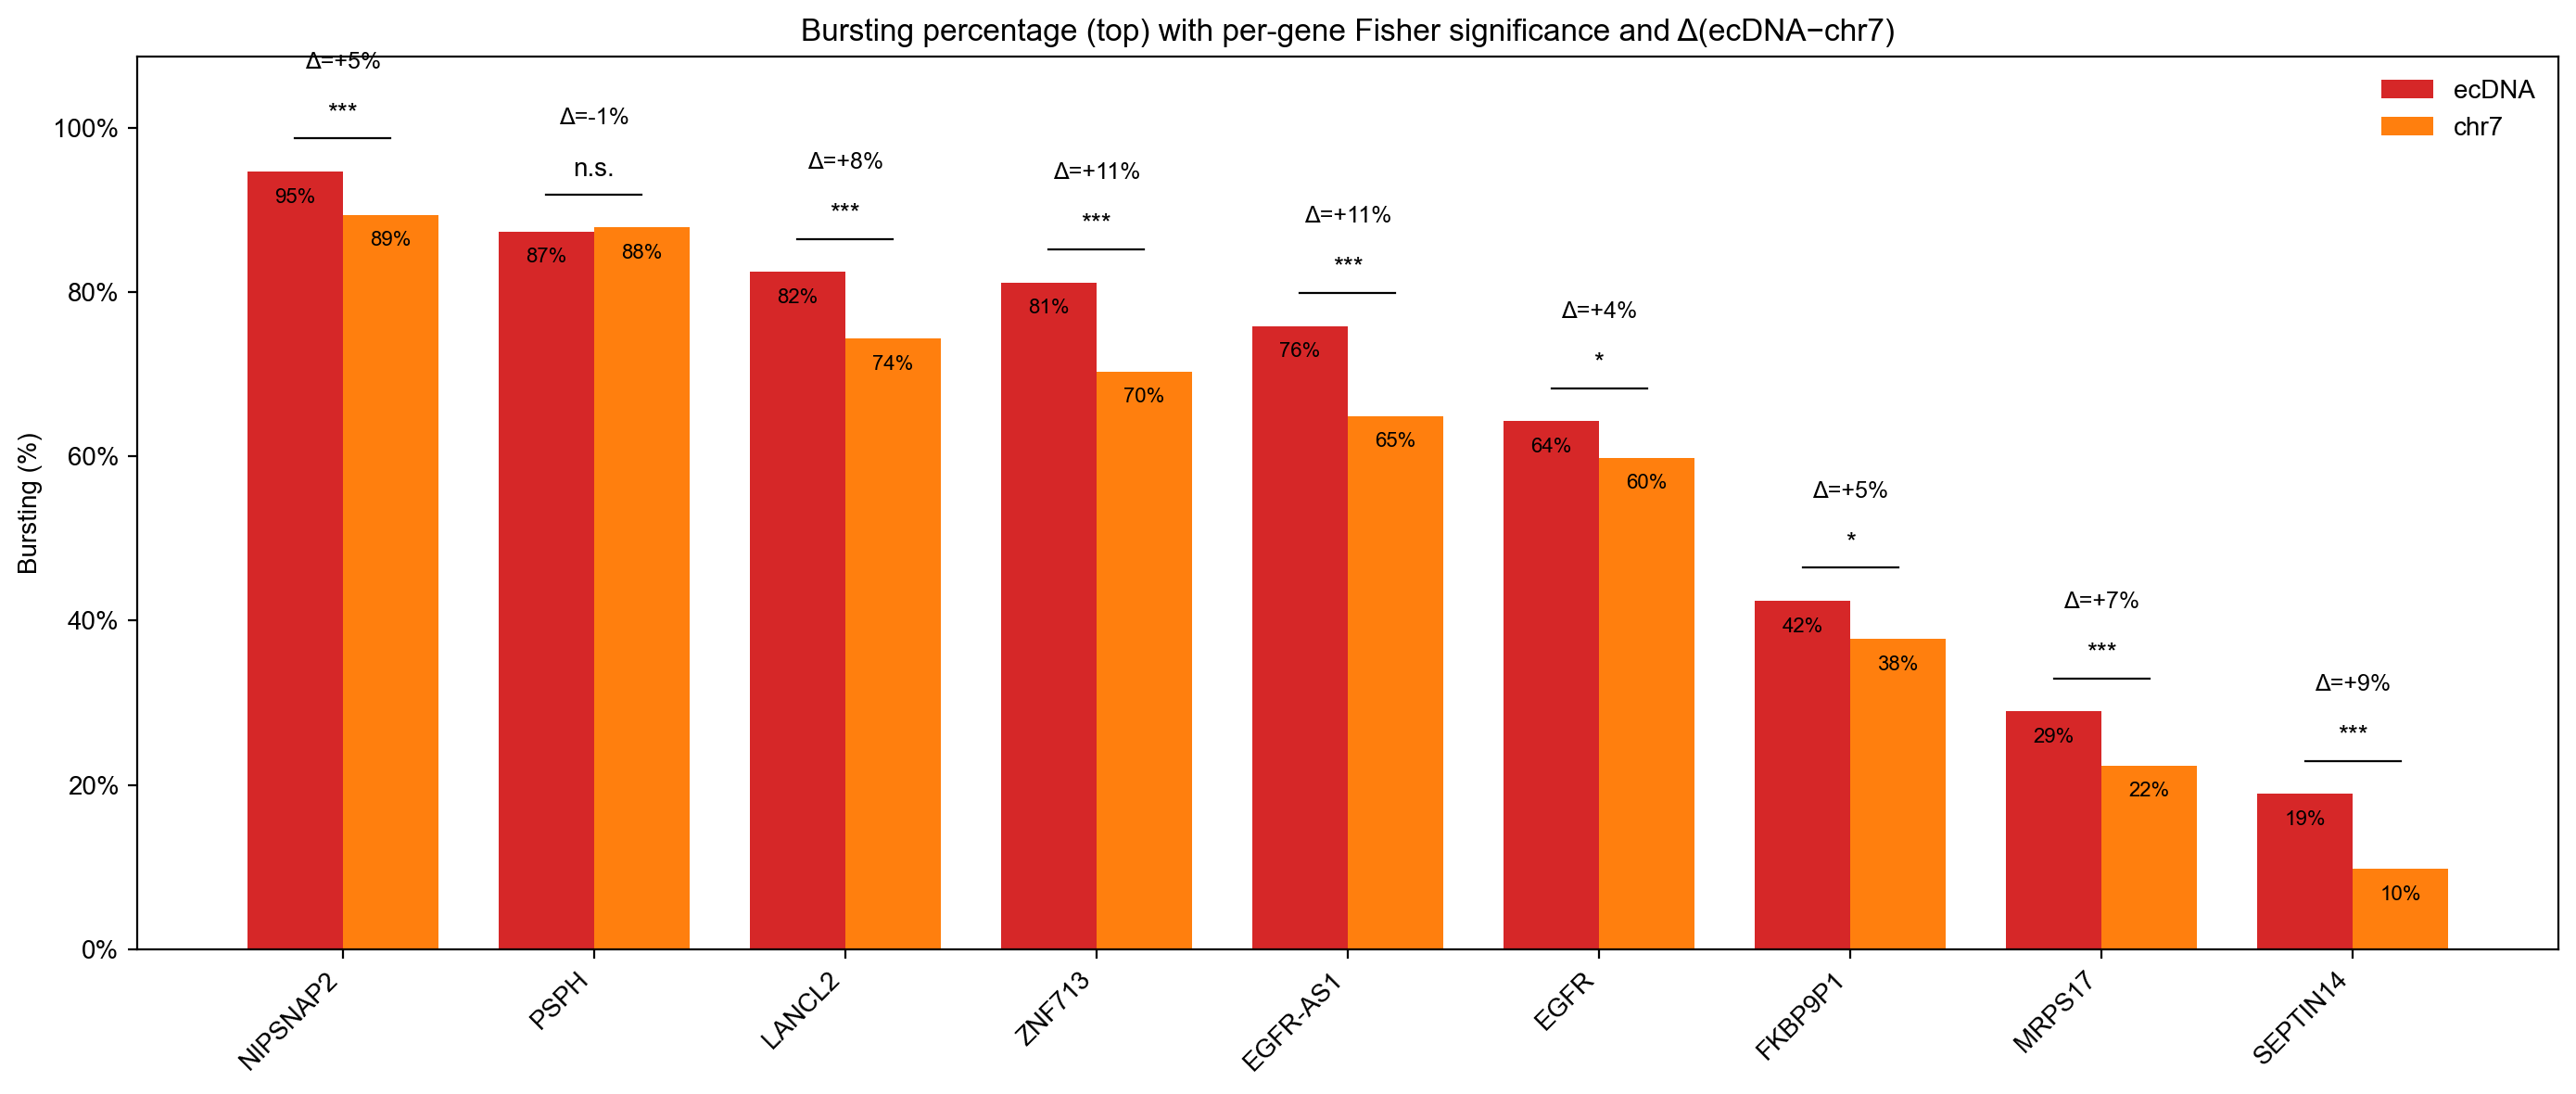

In [14]:
fig, ax = plot_bars_with_fisher_annotations(df_props_, df_pb = pd.DataFrame(), sort_by="p_ecDNA", plot_exon = False,
                                           color_ec = 'C3', color_chr7 = 'C1')
plt.show()

## bursting rate vs. exon expression (TODO)

as validation

# Rg vs. transcription

## quantify transcriptional bursting (TODO)

Rg has been previously computed. Here we are compiling a summary table

## plot Rg vs transcription for each gene

In [4]:
df_cts = pd.read_csv(r'C:/GBM39/invirto_030125/112325__df-global_transcription-rgs-antibody_H__invitro_030125.csv',
                     index_col = 0)

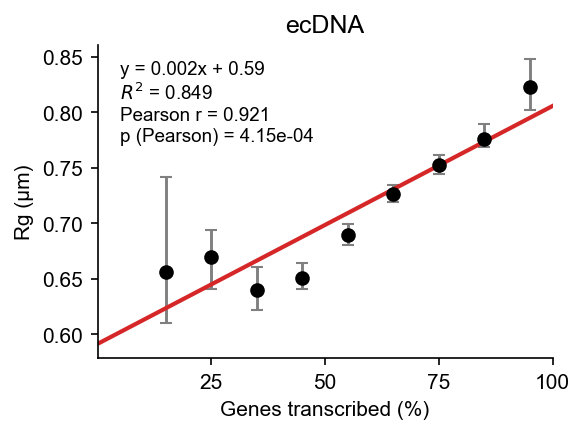

In [6]:
fig, ax, summary, model, _,_ = plot_genes_vs_rgs_percent_bins_binnedR2(
    df_cts[df_cts['pool'] == 'circular'],
    n_groups=10,
    line_color="C3",
    title="ecDNA",
    save_svg=False,
    # svg_path=r"C:/GBM39/manuscript_figures/invitro_fig2/plots/bursting_transcription/ecDNA_global_transcription_bin_95CI.svg"
)
plt.show()


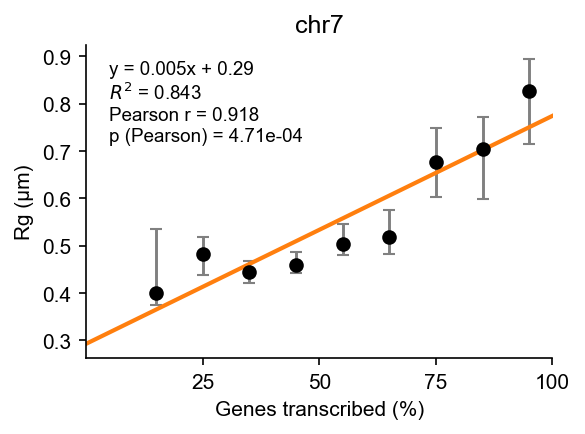

In [7]:
fig, ax, summary, model,_,_ = plot_genes_vs_rgs_percent_bins_binnedR2(
    df_cts[df_cts['pool'] == 'linear'],
    n_groups=10,
    line_color="C1",
    title="chr7",
    save_svg=False,
    # svg_path=r"C:/GBM39/manuscript_figures/invitro_fig2/plots/bursting_transcription/chr7_global_transcription_bin_95CI.svg"
)
plt.show()
